# **CS 559-WS1: Machine Learning: Fundamentals and Applications**
# **Homework 4**

**Name: Ankit Dhandharia**

**CWID: 20033031**

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import time
warnings.filterwarnings('ignore')

In [39]:
# Set random seed for reproducibility
np.random.seed(42)

# Load the preprocessed data from Assignment 3
train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')

In [41]:
train_data.shape

(257, 14)

In [40]:
test_data.shape

(65, 14)

In [42]:
# Split features and target variable
X_train = train_data.drop('Salary', axis=1)
y_train = train_data['Salary']
X_test = test_data.drop('Salary', axis=1)
y_test = test_data['Salary']

In [43]:
# Get the feature names
feature_names = X_train.columns
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Part A: Model Training**

### **1. Neural Network**

In [46]:
# Define MLP hyperparameter options
hidden_layers = [(10,), (20,), (50,), (100,), (10, 10), (20, 10)]
activations = ['relu', 'tanh']
alphas = [0.0001, 0.001, 0.01, 0.1]

# Keep track of model performances
nn_results = []

# Find best params using manual grid search (more control than GridSearchCV)
for hidden in hidden_layers:
    for activation in activations:
        for alpha in alphas:
            nn = MLPRegressor(
                hidden_layer_sizes=hidden,
                activation=activation,
                alpha=alpha,
                max_iter=1000,
                random_state=42
            )

            # Time the training
            start_time = time.time()
            nn.fit(X_train_scaled, y_train)
            train_time = time.time() - start_time

            # Evaluate on train and test sets
            train_pred = nn.predict(X_train_scaled)
            test_pred = nn.predict(X_test_scaled)

            train_r2 = r2_score(y_train, train_pred)
            test_r2 = r2_score(y_test, test_pred)

            nn_results.append({
                'hidden': hidden,
                'activation': activation,
                'alpha': alpha,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_time': train_time
            })

# Find best model
best_nn = max(nn_results, key=lambda x: x['test_r2'])
print(f"Best NN parameters: hidden_layers={best_nn['hidden']}, activation={best_nn['activation']}, alpha={best_nn['alpha']}")
print(f"Best NN test R²: {best_nn['test_r2']:.4f}")

Best NN parameters: hidden_layers=(10, 10), activation=relu, alpha=0.0001
Best NN test R²: 0.5007


In [47]:
# Train final model with best parameters
nn_model = MLPRegressor(
    hidden_layer_sizes=best_nn['hidden'],
    activation=best_nn['activation'],
    alpha=best_nn['alpha'],
    max_iter=1000,
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

In [48]:
# Generate predictions
nn_train_pred = nn_model.predict(X_train_scaled)
nn_test_pred = nn_model.predict(X_test_scaled)

In [49]:
# Calculate metrics
nn_train_mse = mean_squared_error(y_train, nn_train_pred)
nn_train_r2 = r2_score(y_train, nn_train_pred)
nn_test_mse = mean_squared_error(y_test, nn_test_pred)
nn_test_r2 = r2_score(y_test, nn_test_pred)

print(f"Neural Network Training MSE: {nn_train_mse:.2f}")
print(f"Neural Network Training R²: {nn_train_r2:.4f}")
print(f"Neural Network Test MSE: {nn_test_mse:.2f}")
print(f"Neural Network Test R²: {nn_test_r2:.4f}")

Neural Network Training MSE: 101207.33
Neural Network Training R²: 0.3709
Neural Network Test MSE: 96009.06
Neural Network Test R²: 0.5007


In [50]:
# Create learning curve for Neural Network
train_sizes, train_scores, test_scores = learning_curve(
    nn_model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='r2'
)
# Calculate mean and std of training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

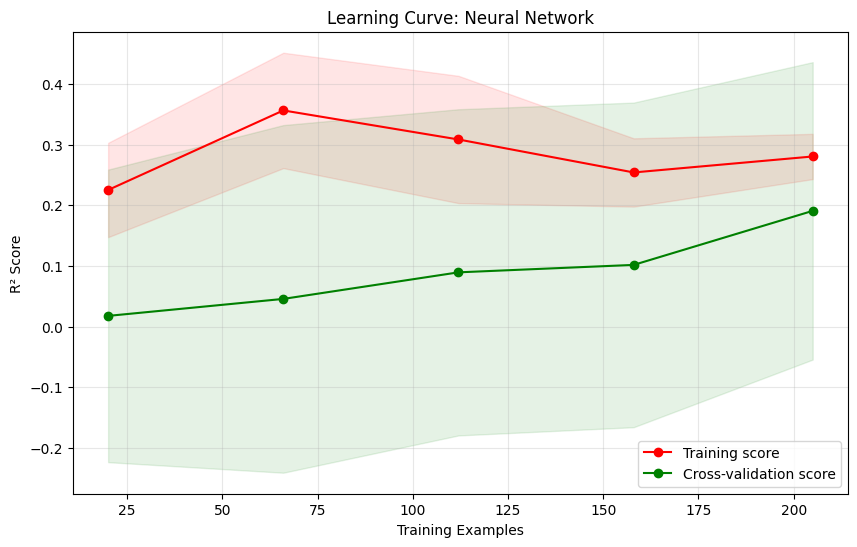

In [51]:
# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Training Examples')
plt.ylabel('R² Score')
plt.title(f'Learning Curve: Neural Network')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
# Plot hyperparameter efficiency for hidden layers
hidden_sizes = ['(10,)', '(20,)', '(50,)', '(100,)', '(10,10)', '(20,10)']
hidden_scores = []
hidden_times = []

for h in hidden_layers:
    results = [r for r in nn_results if r['hidden'] == h and
               r['activation'] == best_nn['activation'] and r['alpha'] == best_nn['alpha']]
    if results:
        hidden_scores.append(results[0]['test_r2'])
        hidden_times.append(results[0]['train_time'])

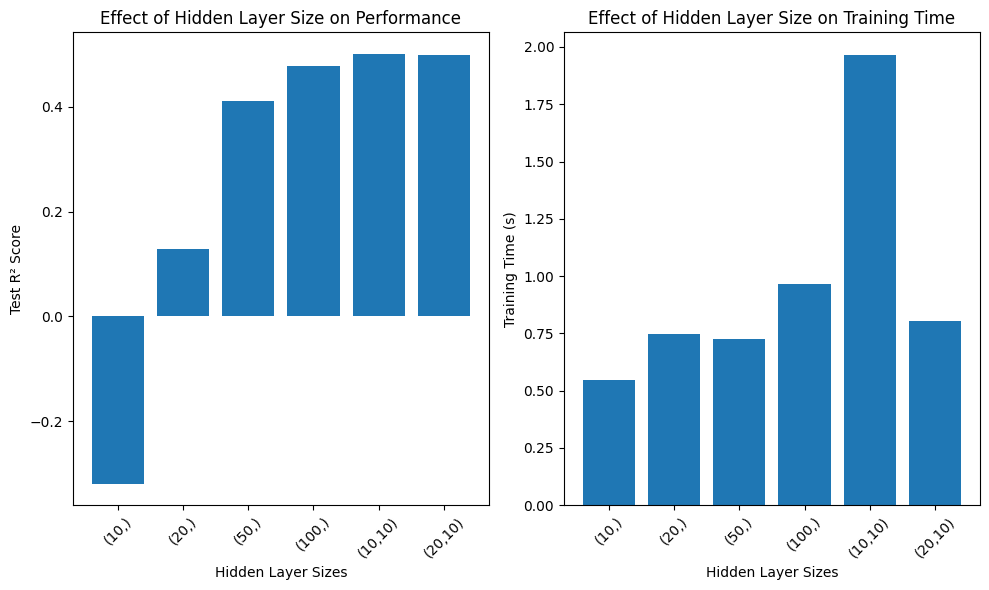

In [53]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(hidden_sizes, hidden_scores)
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Test R² Score')
plt.title('Effect of Hidden Layer Size on Performance')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(hidden_sizes, hidden_times)
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Training Time (s)')
plt.title('Effect of Hidden Layer Size on Training Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()